# Exploratory data analysis of final summary statistics

#### Getting ready

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import numpy as np
import missingno as msno
import os

In [2]:
wd = "/home/maria/git/SOROLLA/"
sumstats = f"{wd}SumStats/"
results = f"{wd}Results/OUTPUTS/"
results_tables_dir = f"{results}tables/"
results_plots_dir = f"{results}plots/"
general = "general/"


os.makedirs(os.path.join(results_tables_dir, general), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, general), exist_ok=True)
general_plots_dir = os.path.join(results_plots_dir, general)
general_tables_dir = os.path.join(results_tables_dir, general)

In [3]:
csv = pd.read_csv(f"{sumstats}excell_sumstats_description.csv")
imputed = pd.read_csv(f"{sumstats}data_description_matrix.csv")

In [4]:
csv.drop(labels="ignore", axis=1, inplace=True)
csv.head()


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and in...",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO
1,NEU,main,Genetic meta-analysis of diagnosed Alzheimer's...,30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN
2,NEU,minor,"Meta-analysis of 74,046 individuals identifies...",24162737,Alzheimer disease,alzheimer's disease,NaN,alzheimers-late-onset-4,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,55134,NaN,17008.0,NaN,37154.0,NaN
3,NEU,main,Common and rare variant association analyses i...,34873335,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-1,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,138086,NaN,27205.0,NaN,110881.0,NaN
4,NEU,minor,Genome-wide association analyses identify new ...,27455348,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-2,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,36052,NaN,12577.0,controls,23475.0,NaN


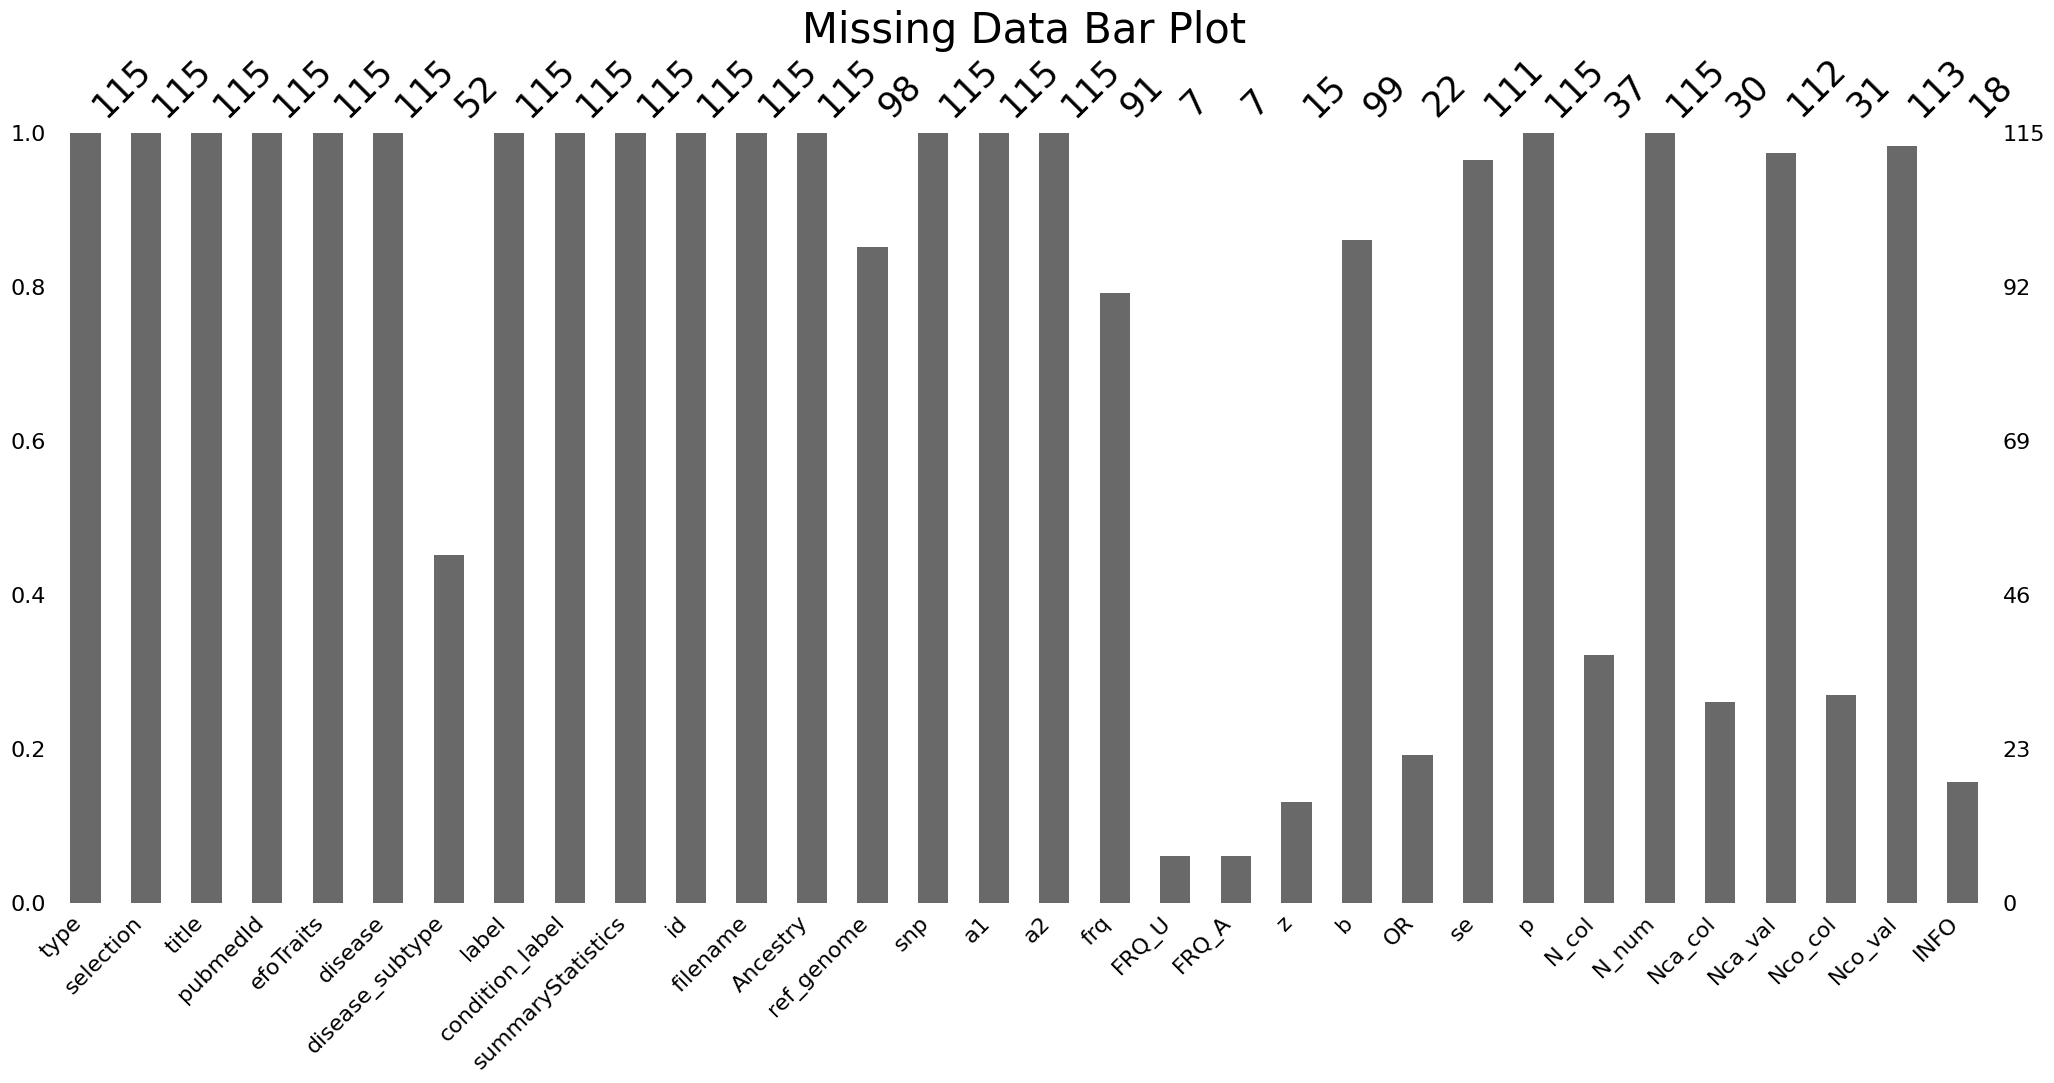

In [5]:
fig, ax = plt.subplots(figsize=(10, 15))

msno.bar(csv)

plt.xticks(fontsize=25) 
plt.yticks(fontsize=25) 
# plt.xlabel('Columns', fontsize=16) 
plt.ylabel('Missing Values Count', fontsize=16)  
plt.title('Missing Data Bar Plot', fontsize=30) 

# Save plot
plt.savefig(f"{general_plots_dir}missing_data_bar_plot_01.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{general_plots_dir}missing_data_bar_plot_01.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{general_plots_dir}missing_data_bar_plot_01.pdf", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


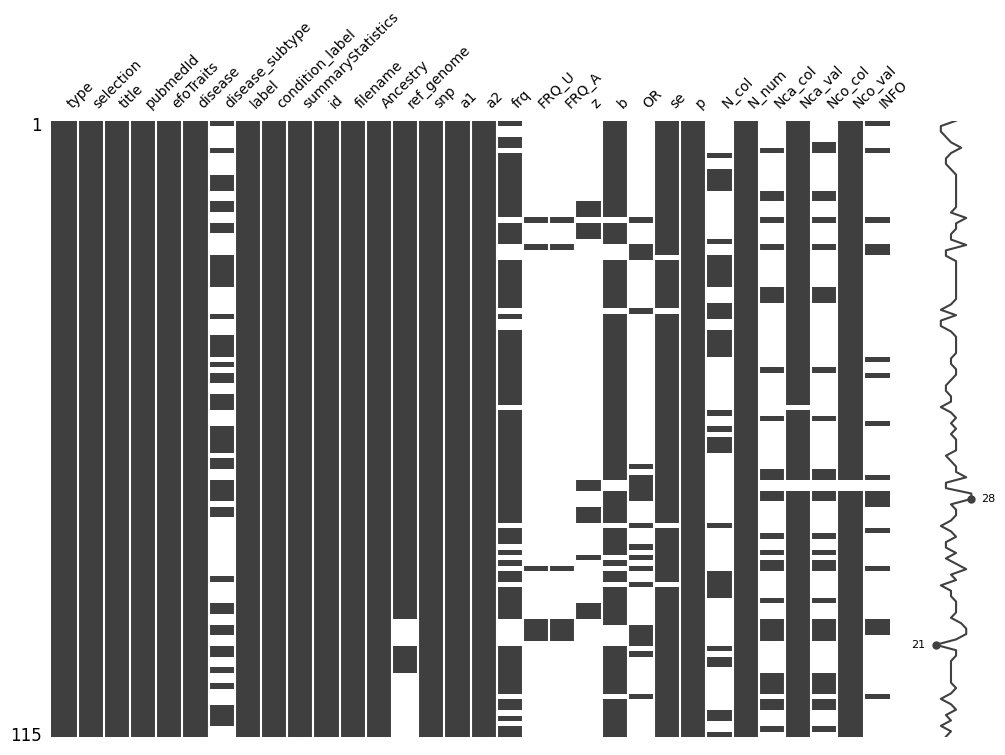

In [6]:
msno = msno.matrix(csv, figsize=(12, 8), fontsize=10)
fig = msno.get_figure()

plt.savefig(f"{general_plots_dir}missing_data_bar_plot_02.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{general_plots_dir}missing_data_bar_plot_02.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{general_plots_dir}missing_data_bar_plot_02.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [7]:
imputed

,id,label,disease,rsID,A1,A2,A1_frequency,zscore,beta,odds_ratio,beta_standard_error,odds_ratio_standard_error,p_value,Ncol,Nca_col,Nco_col,INFO
0,GCST90012878,alzheimers-disease-family-history,alzheimer's disease,1,1,1,1,2,1,0,1,0,1,2,0,0,1
1,GCST007511,alzheimers-late-onset-1,alzheimer's disease,1,1,1,0,2,1,0,1,0,1,2,0,0,0
2,GCST002245,alzheimers-late-onset-4,alzheimer's disease,1,1,1,0,2,1,0,1,0,1,2,0,0,0
3,GCST90027164,lateral-sclerosis-1,amyotrophic lateral sclerosis,1,1,1,1,2,1,0,1,0,1,2,0,0,0
4,GCST004692,lateral-sclerosis-2,amyotrophic lateral sclerosis,1,1,1,1,2,1,0,1,0,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,GCST009158,uterine-fibroid-1,uterus cancer,1,1,1,0,2,1,0,1,0,1,1,0,0,0
111,GCST90042872,uterine-fibroid-leiomyoma,uterus cancer,1,1,1,1,2,1,0,1,0,1,1,0,0,0
112,GCST90239856,uterine-leiomyoma-2,uterus cancer,1,1,1,0,2,1,0,1,0,1,2,0,0,0
113,GCST90436510,uterine-polyp-1,uterus polyps,1,1,1,1,2,1,0,1,0,1,2,1,1,0


In [8]:
imputed["zscore"].value_counts()

2    100
1     15
Name: zscore, dtype: int64

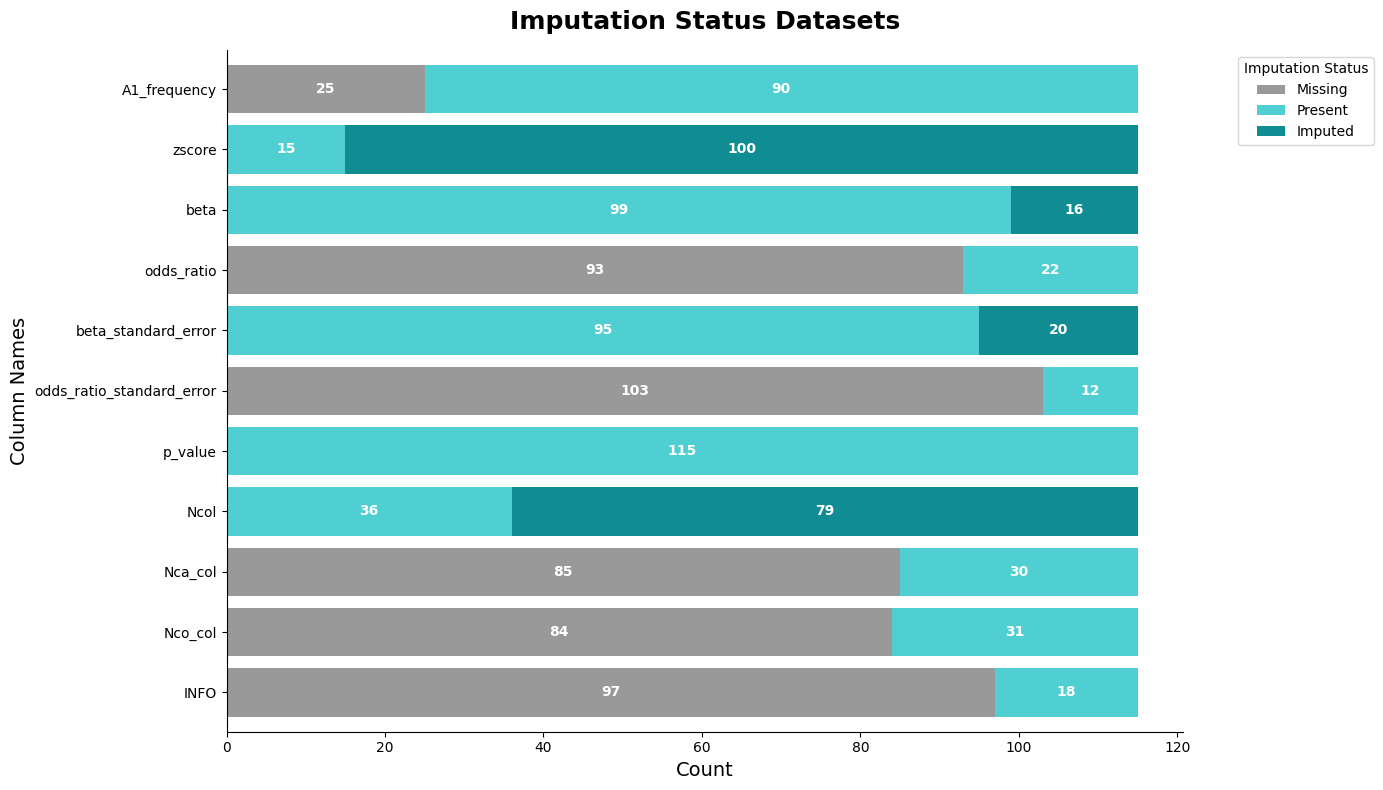

In [104]:
# With imputed values, see the reconstruction of missing values, 0 is not present and not imputed, 1 is present and not imputed, 2 is imputed value
# Barplot of values for the following columns: id	label	disease	rsID	A1	A2	A1_frequency	zscore	beta	odds_ratio	beta_standard_error	odds_ratio_standard_error	p_value	Ncol	Nca_col	Nco_col	INFO
columns_to_plot = ["A1_frequency", "zscore", "beta", "odds_ratio", 
				   "beta_standard_error", "odds_ratio_standard_error", 
				   "p_value", "Ncol", "Nca_col", "Nco_col", "INFO"]

imputed_meaning = {
	0: 'Missing',
	1: 'Present',
	2: 'Imputed'
}

status_order = ['Missing', 'Present', 'Imputed']
status_counts = (
    imputed[columns_to_plot]
    .apply(lambda x: x.value_counts())
    .fillna(0)
    .reindex([0, 1, 2])
    .T
)
status_counts = status_counts[::-1]
status_colors = ["#999999", "#4fcfd1", "#108c93"]

imputed_long = imputed[columns_to_plot].melt(var_name='Column', value_name='Status')
imputed_long['Status_Label'] = imputed_long['Status'].map(imputed_meaning)

fig, ax = plt.subplots(figsize=(14, 8))

status_counts.plot(
    kind='barh', 
    stacked=True, 
    ax=ax,      
    color=status_colors, 
    width=0.8,
    edgecolor='none'
)

for container in ax.containers:
    labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

ax.set_title('Imputation Status Datasets', fontsize=18, pad=15, fontweight='bold')
ax.set_xlabel('Count', fontsize=14)
ax.set_ylabel('Column Names', fontsize=14)

ax.legend(title='Imputation Status', labels=status_order, bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig(f"{general_plots_dir}imputation_summary.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{general_plots_dir}imputation_summary.png", dpi=300, bbox_inches='tight')

plt.show()





In [102]:
status_percentages = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

table_data = {}
status_labels = ['Missing', 'Present', 'Imputed']

for i, label in enumerate(status_labels):
    table_data[f'{label} (n)'] = status_counts[i].astype(int)
    table_data[f'{label} (%)'] = status_percentages[i].map('{:.2f}%'.format)

summary_table = pd.DataFrame(table_data)
display(summary_table)

# Save to excell in the general tables directory
summary_table.to_excel(f"{general_tables_dir}imputation_summary_table.xlsx", index=True)

,Missing (n),Missing (%),Present (n),Present (%),Imputed (n),Imputed (%)
INFO,97,84.35%,18,15.65%,0,0.00%
Nco_col,84,73.04%,31,26.96%,0,0.00%
Nca_col,85,73.91%,30,26.09%,0,0.00%
Ncol,0,0.00%,36,31.30%,79,68.70%
p_value,0,0.00%,115,100.00%,0,0.00%
odds_ratio_standard_error,103,89.57%,12,10.43%,0,0.00%
beta_standard_error,0,0.00%,95,82.61%,20,17.39%
odds_ratio,93,80.87%,22,19.13%,0,0.00%
beta,0,0.00%,99,86.09%,16,13.91%
zscore,0,0.00%,15,13.04%,100,86.96%


In [17]:
type_palette = {"CAN":"#FE6401", "PSY":"#BA41C7","NEU":"#47AA4F"}

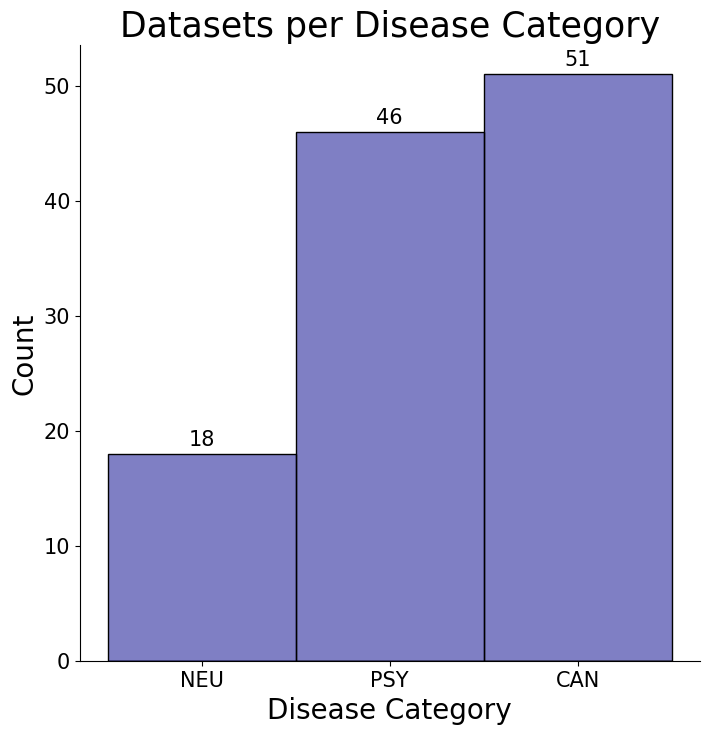

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

a = sns.histplot(csv, x = "type", hue = "type", palette=['darkblue']*len(csv['type'].unique()), legend=None, ax=ax)
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3, fontsize=15)

sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Disease Category', fontsize=20) 
plt.ylabel('Count', fontsize=20)  
plt.title('Datasets per Disease Category', fontsize=25) 

# Display the plot
plt.show()

/tmp/ipykernel_1008482/1660268633.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  a = sns.histplot(unique_diseases, x='type', weights='unique_disease_count', palette=['darkblue']*len(unique_diseases['type'].unique()), ax=ax)


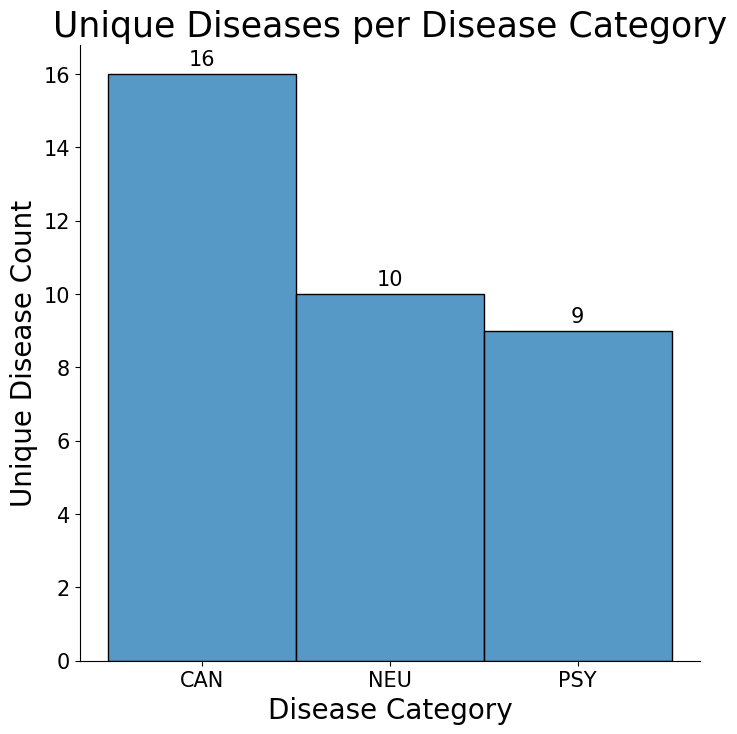

In [19]:
unique_diseases = csv.groupby('type')['disease'].nunique().reset_index()
unique_diseases.columns = ['type', 'unique_disease_count']

fig, ax = plt.subplots(figsize=(8, 8))
a = sns.histplot(unique_diseases, x='type', weights='unique_disease_count', palette=['darkblue']*len(unique_diseases['type'].unique()), ax=ax)

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=15)

sns.despine()

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Disease Category', fontsize=20)
plt.ylabel('Unique Disease Count', fontsize=20)
plt.title('Unique Diseases per Disease Category', fontsize=25)

plt.show()


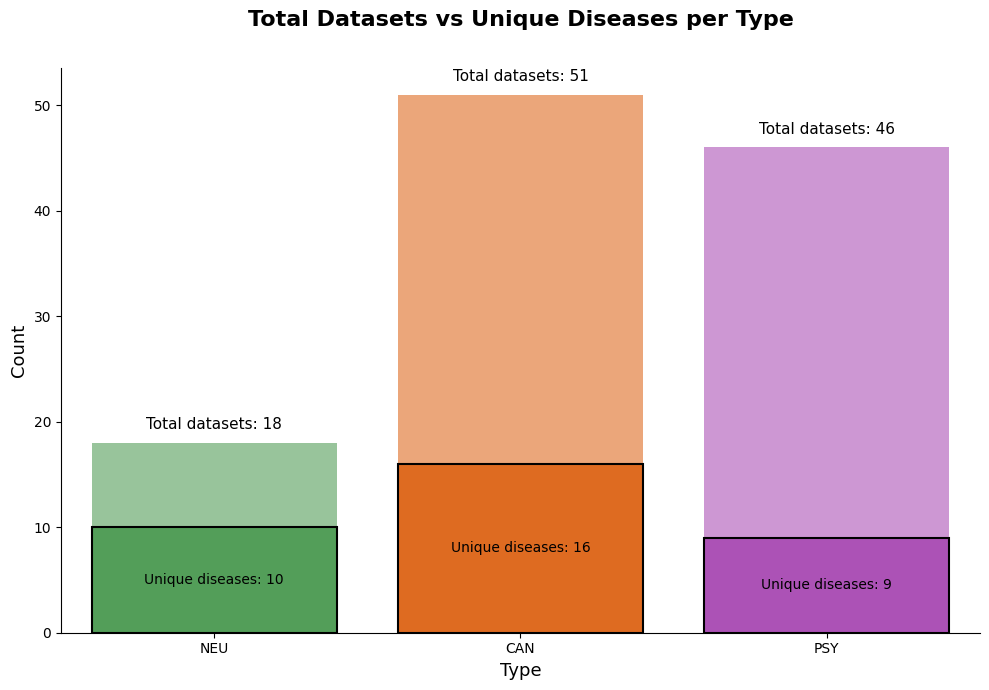

In [80]:
type_summary = csv.groupby('type').agg(
    Total_Datasets=('type', 'count'),
    Unique_Diseases=('disease', 'nunique')
).reset_index()

type_order = ['NEU', 'CAN', 'PSY']
type_summary['type'] = pd.Categorical(type_summary['type'], categories=type_order, ordered=True)
type_summary = type_summary.sort_values('type')

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=type_summary, x='type', y='Total_Datasets', 
    palette=type_palette, ax=ax, label='Total Datasets', alpha=0.6
)
sns.barplot(
    data=type_summary, x='type', y='Unique_Diseases', 
    palette=type_palette, ax=ax, label='Unique Diseases', edgecolor='black', linewidth=1.5
)

for i, row in enumerate(type_summary.itertuples()):
    ax.text(i, row.Unique_Diseases / 2, f'Unique diseases: {row.Unique_Diseases}', 
            ha='center', va='center', color='black')
    
    ax.text(i, row.Total_Datasets + 1, f'Total datasets: {row.Total_Datasets}', 
            ha='center', va='bottom', fontsize=11)

ax.set_title('Total Datasets vs Unique Diseases per Type', fontsize=16, pad=30, fontweight='bold')
ax.set_ylabel('Count', fontsize=13)
ax.set_xlabel('Type', fontsize=13)
sns.despine()

plt.tight_layout()
plt.savefig(f"{results_plots}/datasets_per_disease_and_unique_countplot.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_disease_and_unique_countplot.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_disease_and_unique_countplot.pdf", dpi=300, bbox_inches='tight')

plt.show()


In [10]:
print(f"The number of unique diseases in the dataset is", len(csv["disease"].unique()))
print(f"The number of unique pubmedIds in the dataset is", len(csv["pubmedId"].unique()))

The number of unique diseases in the dataset is 35
The number of unique pubmedIds in the dataset is 40


In [18]:
summary = csv.groupby(['disease', 'type', 'selection']).size().unstack(fill_value=0)
summary['total_count'] = summary.sum(axis=1)
summary = summary.reset_index()
table_disease_type_count_subtype = summary.sort_values(by=['type', 'disease'], ascending=True)
table_disease_type_count_subtype

selection,disease,type,main,minor,subtype,subtype-family,total_count
7,breast cancer,CAN,1,5,2,2,10
8,cervical cancer,CAN,1,0,0,0,1
9,colorectal cancer,CAN,1,2,1,0,4
10,endometrial cancer,CAN,1,1,0,0,2
12,esophaegal cancer,CAN,1,0,0,0,1
13,glaucoma,CAN,1,0,0,0,1
15,intestinal cancer,CAN,0,0,0,1,1
16,lung cancer,CAN,1,0,3,3,7
17,lymph node cancer,CAN,1,0,0,0,1
19,melanoma,CAN,1,0,0,0,1


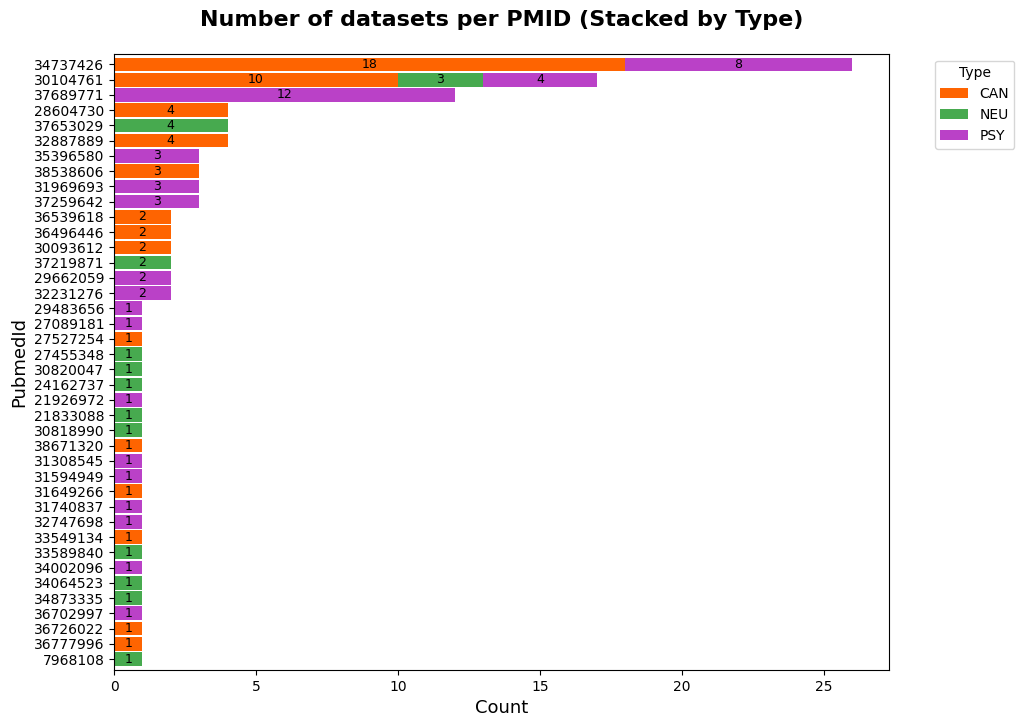

In [45]:
pmid_pivot_type = csv.groupby(['pubmedId', 'type']).size().unstack(fill_value=0)
pmid_pivot_type['total'] = pmid_pivot_type.sum(axis=1)
pmid_pivot_type = pmid_pivot_type.sort_values('total', ascending=True).drop(columns='total')

ax = pmid_pivot_type.plot(kind='barh', stacked=True, figsize=(10, 8),
                          edgecolor='none', 
                          width=0.9,
                          color=[type_palette.get(x, '#gray') for x in pmid_pivot_type.columns],
                          linewidth=1)

for container in ax.containers:
    labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

plt.xlabel('Count', fontsize=13)
plt.ylabel('PubmedId', fontsize=13)
plt.title('Number of datasets per PMID (Stacked by Type)', fontweight='bold', pad=20, fontsize=16)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(f"{results_plots}/datasets_per_pmid_countplot.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_pmid_countplot.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_pmid_countplot.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [41]:
# Calculate the counts of each disease category and sort them
disease_counts = csv['disease'].value_counts().sort_values(ascending=False)
sorted_disease_order = disease_counts.index

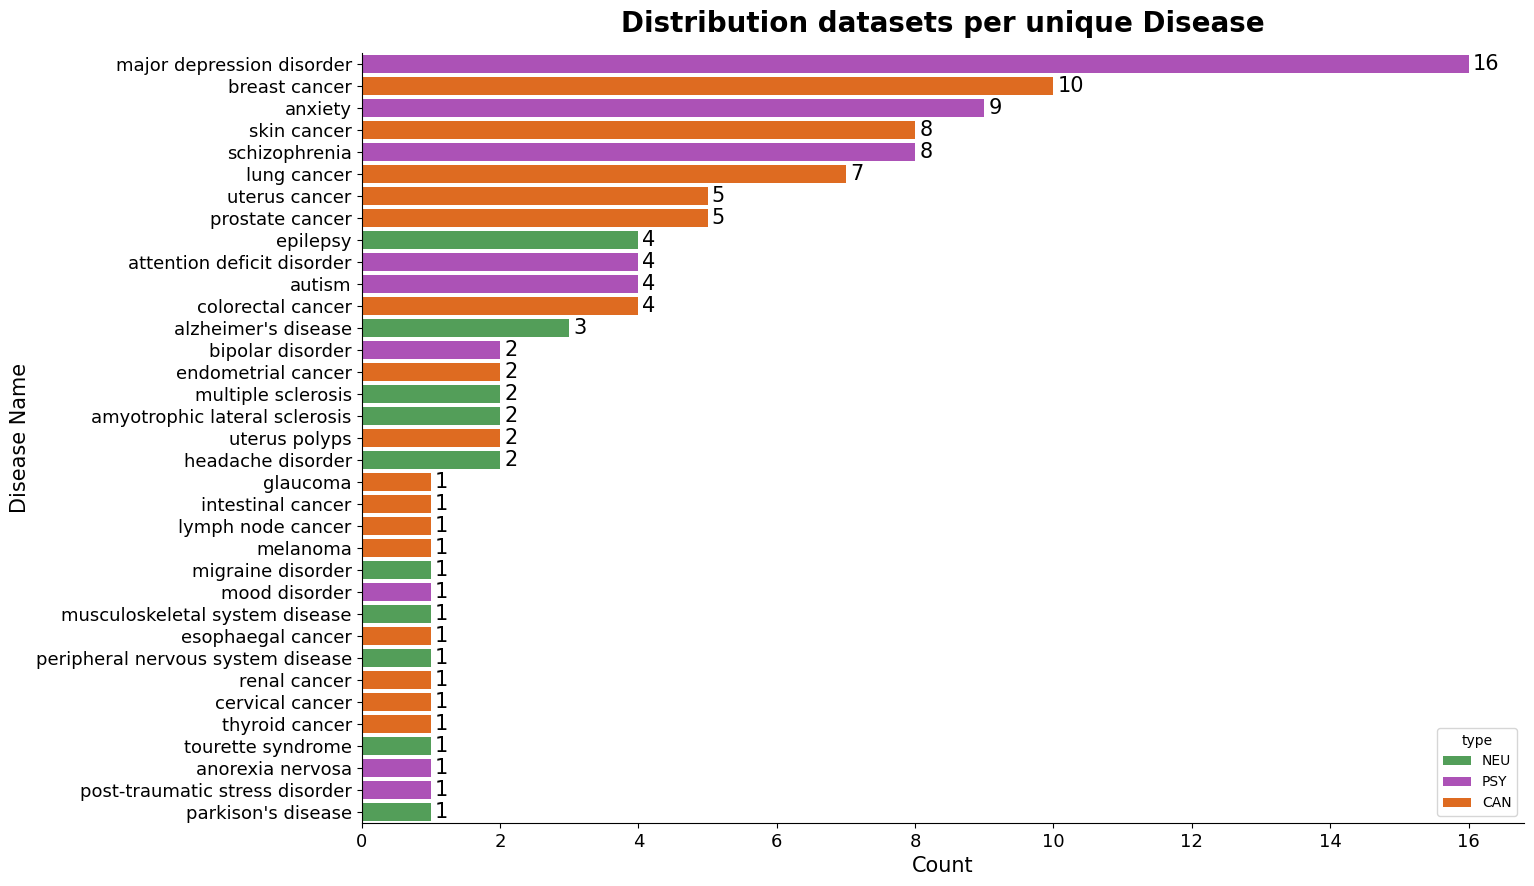

In [46]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.countplot(data=csv, y='disease', hue='type', order=sorted_disease_order, palette=type_palette, ax=ax, dodge=False)

for container in ax.containers:
    labels = [f'{int(height)}' if height > 0 else '' for height in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=15)


sns.despine()

plt.xticks(fontsize=13) 
plt.yticks(fontsize=13) 
plt.xlabel('Count', fontsize=15) 
plt.ylabel('Disease Name', fontsize=15)  
plt.title('Distribution datasets per unique Disease', fontsize=20, pad=15, fontweight='bold') 

plt.savefig(f"{results_plots}/datasets_per_disease_countplot.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_disease_countplot.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_disease_countplot.pdf", dpi=300, bbox_inches='tight')

plt.show()


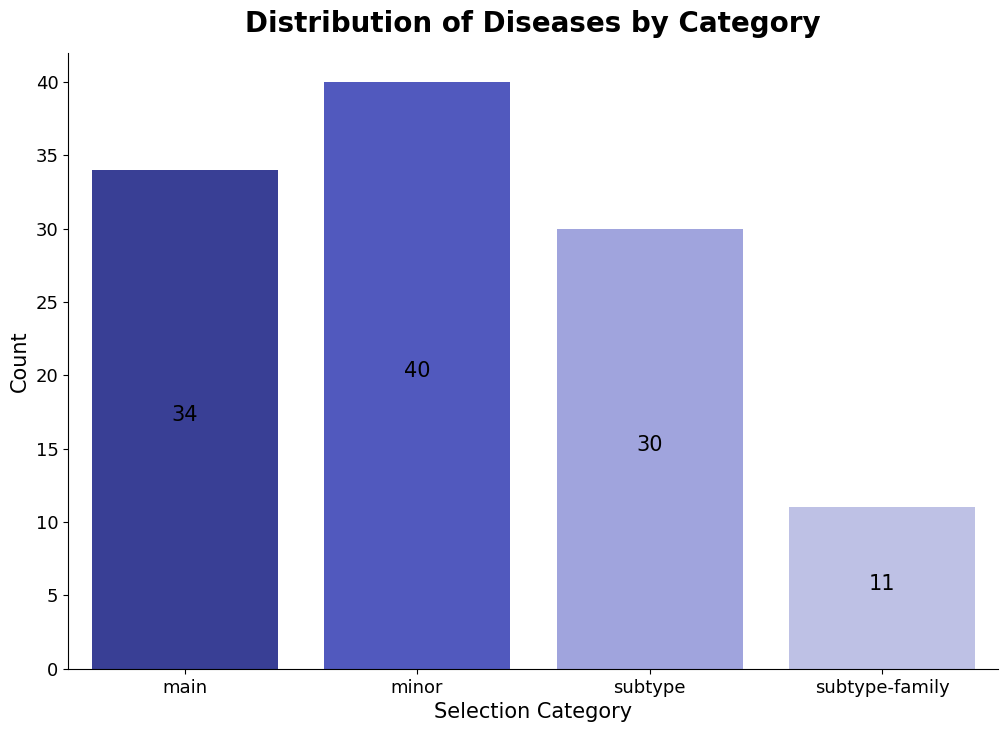

In [78]:
gray_palette = {
    "main": "#2A32A4",
    "minor": "#3F49D0",
    "subtype": "#969BE7",
    "subtype-family": "#B7BBEC",
}

fig, ax = plt.subplots(figsize=(12, 8))

c = sns.countplot(csv, x="selection", palette=gray_palette, ax=ax)

for container in c.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    c.bar_label(container, labels=labels, label_type="center", padding=3, fontsize = 15)
    
sns.despine()

plt.xticks(fontsize=13) 
plt.yticks(fontsize=13) 
plt.xlabel('Selection Category', fontsize=15) 
plt.ylabel('Count', fontsize=15)  
plt.title('Distribution of Diseases by Category', fontsize=20, pad=15, fontweight='bold') 

plt.savefig(f"{results_plots}/datasets_per_selection_countplot.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_selection_countplot.jpg", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_plots}/datasets_per_selection_countplot.pdf", dpi=300, bbox_inches='tight')

plt.show()


NameError: name 'results_plots' is not defined

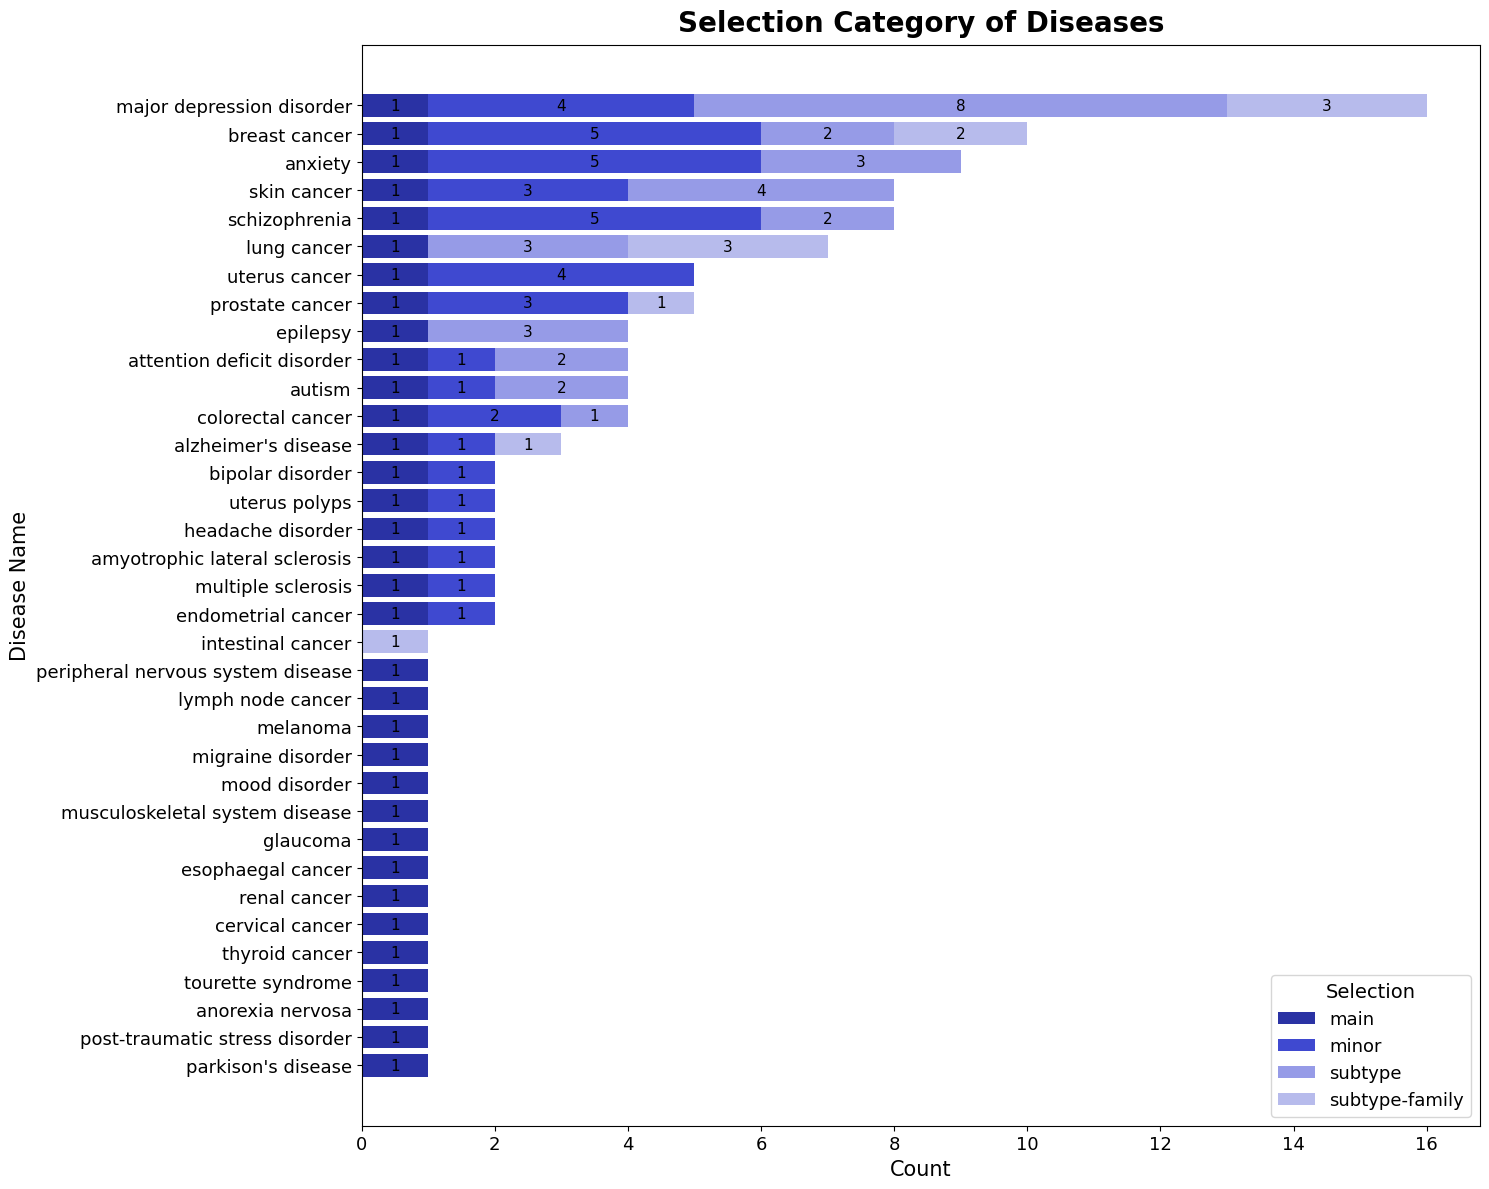

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

csv["selection"] = csv["selection"].astype(str).str.strip().str.lower()
csv["disease"] = csv["disease"].astype(str).str.strip()

sel_order = ["main", "minor", "subtype", "subtype-family"]
disease_order = csv["disease"].value_counts().sort_values(ascending=True).index

counts = (
    pd.crosstab(csv["disease"], csv["selection"])
    .reindex(index=disease_order, columns=sel_order)
    .fillna(0)
)

gray_palette = {
    "main": "#2A32A4",
    "minor": "#3F49D0",
    "subtype": "#969BE7",
    "subtype-family": "#B7BBEC",
}

fig, ax = plt.subplots(figsize=(15, 12))

left = np.zeros(len(counts))
y = np.arange(len(counts))

for k in sel_order:
    vals = counts[k].to_numpy()
    ax.barh(y, vals, left=left, color=gray_palette[k], height=0.8, label=k)
    centers = left + vals / 2
    for yi, v, xc in zip(y, vals, centers):
        if v > 0:
            ax.text(xc, yi, f"{int(v)}", ha="center", va="center", fontsize=11, color="black")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(counts.index, fontsize=13)
ax.tick_params(axis="x", labelsize=13)

ax.set_ylabel("Disease Name", fontsize=15)
ax.set_xlabel("Count", fontsize=15)
ax.set_title("Selection Category of Diseases", fontsize=20, pad=10, fontweight="bold")

legend_handles = [Patch(facecolor=gray_palette[k], edgecolor="none", label=k) for k in sel_order]
ax.legend(handles=legend_handles, title="Selection", loc="lower right",
          frameon=True, fontsize=13, title_fontsize=14)

plt.tight_layout()
plt.savefig(f"{results_plots}/selection_category_diseases.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{results_plots}/selection_category_diseases.jpg", dpi=300, bbox_inches="tight")
plt.savefig(f"{results_plots}/selection_category_diseases.pdf", dpi=300, bbox_inches="tight")
plt.show()

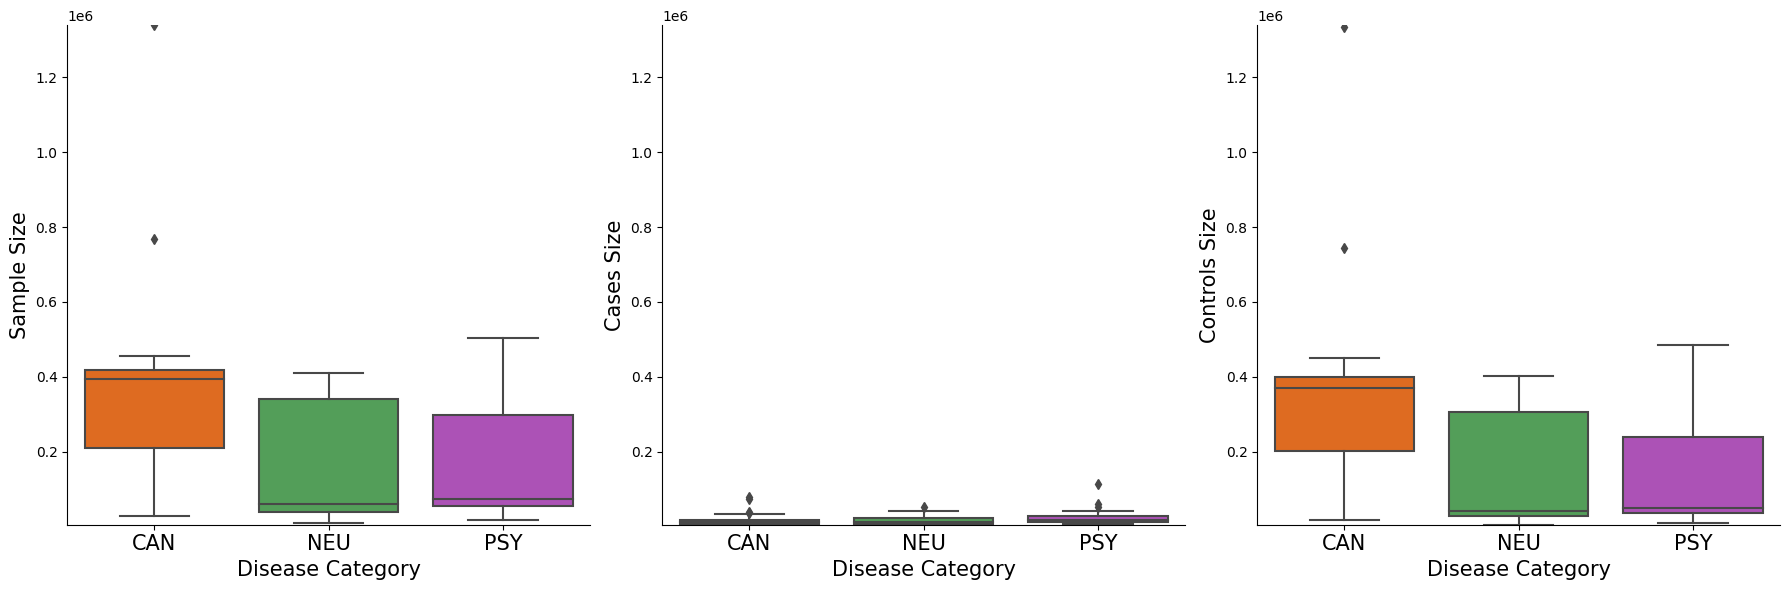

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Determine the global y-axis limits
y_min = min(csv[['N_num', 'Nca_val', 'Nco_val']].min())
y_max = max(csv[['N_num', 'Nca_val', 'Nco_val']].max())

# Boxplot for N_num
sns.boxplot(x='type', y='N_num', data=csv, ax=axes[0], palette=type_palette)
# axes[0].set_title('Sample Size by Disease Category', fontsize=20)
axes[0].set_xlabel('Disease Category', fontsize=15)
axes[0].set_ylabel('Sample Size', fontsize=15)
axes[0].set_ylim(y_min, y_max)

# Boxplot for Nca_val
sns.boxplot(x='type', y='Nca_val', data=csv, ax=axes[1], palette=type_palette)
# axes[1].set_title('Cases Size by Disease Category', fontsize=20)
axes[1].set_xlabel('Disease Category', fontsize=15)
axes[1].set_ylabel('Cases Size', fontsize=15)
axes[1].set_ylim(y_min, y_max)

# Boxplot for Nco_val
sns.boxplot(x='type', y='Nco_val', data=csv, ax=axes[2], palette=type_palette)
# axes[2].set_title('Cases Size by Disease Category', fontsize=20)
axes[2].set_xlabel('Disease Category', fontsize=15)
axes[2].set_ylabel('Controls Size', fontsize=15)
axes[2].set_ylim(y_min, y_max)

# Increase x-tick label sizes
for ax in axes:
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=10)

# Adjust layout for better readability and remove spines
plt.tight_layout()
sns.despine()
plt.show()



In [79]:
# plt.figure(figsize=(14, 8))
# bubble_plot = sns.scatterplot(
#     data=csv, 
#     x="Nco_val", 
#     y="Nca_val", 
#     size="N_num", 
#     sizes=(20, 5000),  # Adjust these values to scale bubbles appropriately
#     alpha=0.6,
#     hue="type",
#     legend="brief",
# 	palette=type_palette
# )

# handles, labels = bubble_plot.get_legend_handles_labels()
# new_handles = [h for h, l in zip(handles, labels) if l != 'N_num']
# new_labels = [l for l in labels if l != 'N_num']
# plt.legend(handles=new_handles, labels=new_labels, title='Type')

# plt.title('Bubble Plot of Sample Sizes')
# plt.xlabel('Number of Cases (Nca_val)')
# plt.ylabel('Number of Controls (Nco_val)')



In [80]:
# sns.catplot(data=csv, y="type", x="N_num", hue="Nca_val")

In [81]:
can = csv[csv["type"]=="CAN"]
psy = csv[csv["type"]=="PSY"]
neu = csv[csv["type"]=="NEU"]

In [82]:
# sns.catplot(data=can, y="disease", x="N_num", hue="Nca_val")
# plt.xlabel('Total Sample Size')
# plt.ylabel('Disease name')
# plt.title('Total Size distribution segregated by Case size')

In [83]:
# sns.catplot(data=psy, y="disease", x="N_num", hue="Nca_val")
# plt.xlabel('Total Sample Size')
# plt.ylabel('Disease name')
# plt.title('Total Size distribution segregated by Case size')

In [84]:
# sns.catplot(data=neu, y="disease", x="N_num", hue="Nca_val")
# plt.xlabel('Total Sample Size')
# plt.ylabel('Disease name')
# plt.title('Total Size distribution segregated by Case size')

In [85]:
csv['combination'] = (csv['z'].notnull().astype(int).astype(str) + 
                      csv['b'].notnull().astype(int).astype(str) + 
                      csv['OR'].notnull().astype(int).astype(str))

# Binary representation to see whether the column has a value according to the combination
combination_labels = {
    '100': 'Z-SCORE',
    '010': 'BETA',
    '001': 'ODDS RATIO',
    '110': 'Z-SCORE AND BETA',
    '101': 'Z-SCORE AND ODDS RATIO',
    '011': 'BETA AND ODDS RATIO',
    '111': 'ALL THREE',
	'000': 'NONE'
}
csv['combination'] = csv['combination'].map(combination_labels)

combination_counts = csv['combination'].value_counts().reset_index()
combination_counts.columns = ['Combination', 'Count']

Text(0.5, 1.0, 'Distribution of Studies by Presence of z, b, OR')

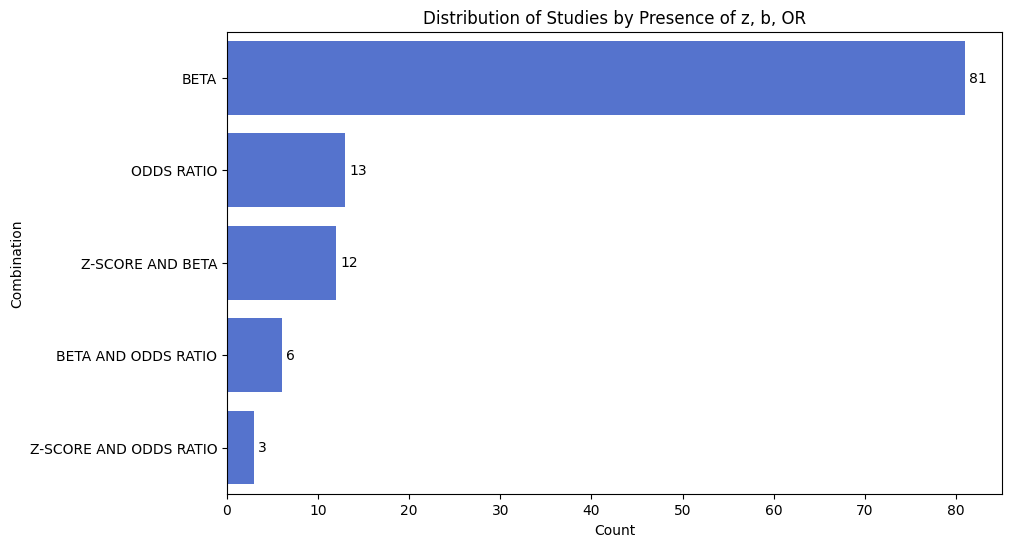

In [86]:
plt.figure(figsize=(10, 6))
a = sns.barplot(x='Count', y='Combination', data=combination_counts, color="royalblue")

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3)
    
plt.xlabel('Count')
plt.ylabel('Combination')
plt.title('Distribution of Studies by Presence of z, b, OR')


In [87]:
se_count = csv["se"].fillna("Missing").value_counts()
se_count = se_count
se_count

standard_error    89
SE                15
Missing            4
StandardError      2
se                 2
STDERR             1
StdErr             1
LOG(OR)_SE         1
Name: se, dtype: int64

Text(0.5, 1.0, 'SE')

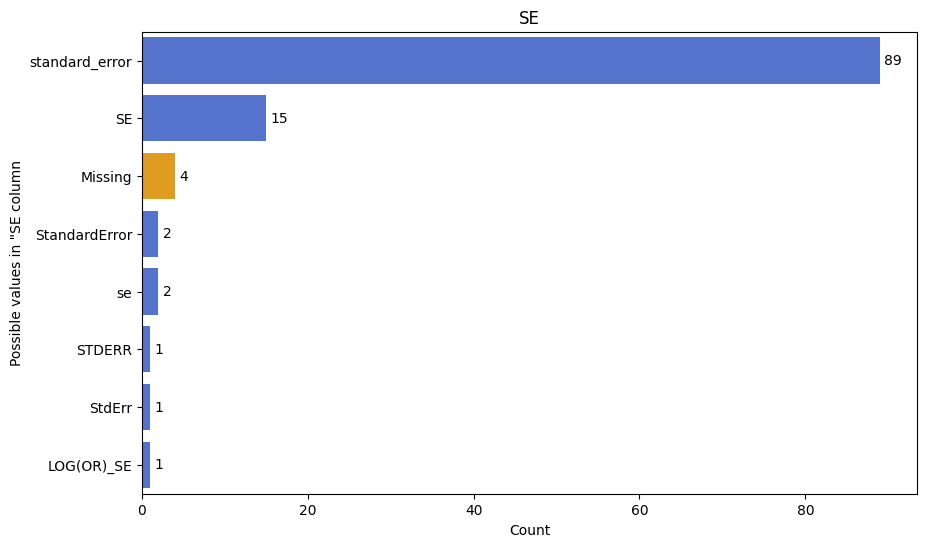

In [88]:
clrs = ['orange' if (x == "Missing") else 'royalblue' for x in se_count.index]

plt.figure(figsize=(10, 6)) 
a = sns.barplot(y=se_count.index, x=se_count.values, palette=clrs) 

for container in a.containers: 
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues] 
    a.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.xlabel('Count')
plt.ylabel('Possible values in "SE column')
plt.title('SE')


In [89]:
missing_beta_se = csv[csv["OR"].isna() & csv["se"].isna()]

In [90]:
missing_beta_se

,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,combination


In [91]:
missing_se = csv[csv["se"].isna()]
missing_se

,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,combination
25,CAN,minor,Pan-cancer study detects genetic risk variants...,32887889,breast carcinoma,breast cancer,carcinoma,breast-carcinoma-1,BRCA,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,p_value,totN,428231,NaN,17881.0,NaN,410350.0,NaN,ODDS RATIO
86,CAN,main,Pan-cancer study detects genetic risk variants...,32887889,prostate carcinoma,prostate cancer,NaN,prostate-cancer-3,PCa,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,p_value,totN,421142,NaN,10792.0,NaN,410350.0,NaN,ODDS RATIO
75,CAN,main,Pan-cancer study detects genetic risk variants...,32887889,melanoma,melanoma,NaN,melanoma-1,SKIN,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,p_value,totN,417127,NaN,6777.0,NaN,410350.0,NaN,ODDS RATIO
35,CAN,main,Pan-cancer study detects genetic risk variants...,32887889,cervical carcinoma,cervical cancer,NaN,cervical-cancer-2,CC,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,p_value,totN,416913,NaN,6563.0,NaN,410350.0,NaN,ODDS RATIO
